# Experiment 03: Study of Frequency Allocation and Channel Assignment in Cellular Networks

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 5 (Frequency Management and Channel Assignment) and the course Master Study Notes.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To study cellular frequency allocation and implement a simple fixed channel assignment model in Python.

## Objectives

- Understand frequency management and channel assignment.
- Distinguish fixed and dynamic/non-fixed channel assignment.
- Allocate channels among cells using a simple reuse-friendly pattern.
- Simulate call demand, served calls, and blocked calls.
- Explain why fixed allocation can leave channels idle in one cell while another cell is congested.

## Theory

In the course material, **frequency management** includes designation of set-up and voice channels, numbering channels, and grouping voice channels into subsets.

**Channel assignment** means allocating particular radio channels to cell sites and mobile units. A cell may receive a channel set on a long-term basis, while a mobile receives one channel from that set only for the duration of a call.

### Fixed Channel Assignment (FCA)

In FCA, each cell has a predetermined channel set:

$$
\mathcal{C}_k=\{\text{channels permanently assigned to cell }k\}
$$

If every channel in $\mathcal{C}_k$ is busy, a new call in that cell is blocked even if another cell has idle channels.

### Dynamic / Non-Fixed Channel Assignment

In dynamic or non-fixed assignment, channels are drawn from a common or adaptable pool according to current demand and interference conditions. This improves flexibility but requires more real-time control.

### Simplified allocation used in this notebook

To avoid assigning many adjacent channel numbers to the same cell, channels are distributed cyclically:

$$
\text{Cell index} = ((\text{channel}-1)\bmod N_c)+1
$$

where $N_c$ is the number of cells in the reuse cluster.

This is an educational allocation rule—not a complete commercial frequency-planning algorithm.

## Procedure

1. Select the number of cells and total available traffic channels.
2. Distribute channels cyclically among cells.
3. Specify busy-hour call demand for each cell.
4. Compare demand with the number of channels assigned to each cell.
5. Count served calls and blocked calls.
6. Plot cell demand versus fixed channel capacity.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configurable parameters
number_of_cells = 7
total_channels = 70

def fixed_channel_assignment(total_channels, number_of_cells):
    assignment = {f"Cell {i+1}": [] for i in range(number_of_cells)}
    for channel in range(1, total_channels + 1):
        cell_index = (channel - 1) % number_of_cells
        assignment[f"Cell {cell_index + 1}"].append(channel)
    return assignment

assignment = fixed_channel_assignment(total_channels, number_of_cells)

for cell, channels in assignment.items():
    print(f"{cell}: {channels}")

Cell 1: [1, 8, 15, 22, 29, 36, 43, 50, 57, 64]
Cell 2: [2, 9, 16, 23, 30, 37, 44, 51, 58, 65]
Cell 3: [3, 10, 17, 24, 31, 38, 45, 52, 59, 66]
Cell 4: [4, 11, 18, 25, 32, 39, 46, 53, 60, 67]
Cell 5: [5, 12, 19, 26, 33, 40, 47, 54, 61, 68]
Cell 6: [6, 13, 20, 27, 34, 41, 48, 55, 62, 69]
Cell 7: [7, 14, 21, 28, 35, 42, 49, 56, 63, 70]


**Interpretation:** With 70 channels and 7 cells, each cell receives 10 fixed channels. The channel numbers in one cell are separated by seven channel positions in this simplified pattern.

In [2]:
# Example busy-hour demand: number of simultaneous call requests
call_requests = {
    "Cell 1": 8,
    "Cell 2": 13,
    "Cell 3": 6,
    "Cell 4": 10,
    "Cell 5": 15,
    "Cell 6": 7,
    "Cell 7": 11,
}

rows = []
for cell, channels in assignment.items():
    capacity = len(channels)
    demand = call_requests[cell]
    served = min(capacity, demand)
    blocked = max(0, demand - capacity)
    idle = max(0, capacity - demand)

    rows.append({
        "Cell": cell,
        "Assigned Channels": capacity,
        "Call Requests": demand,
        "Served Calls": served,
        "Blocked Calls": blocked,
        "Idle Channels": idle
    })

df = pd.DataFrame(rows)
df

,Cell,Assigned Channels,Call Requests,Served Calls,Blocked Calls,Idle Channels
0,Cell 1,10,8,8,0,2
1,Cell 2,10,13,10,3,0
2,Cell 3,10,6,6,0,4
3,Cell 4,10,10,10,0,0
4,Cell 5,10,15,10,5,0
5,Cell 6,10,7,7,0,3
6,Cell 7,10,11,10,1,0


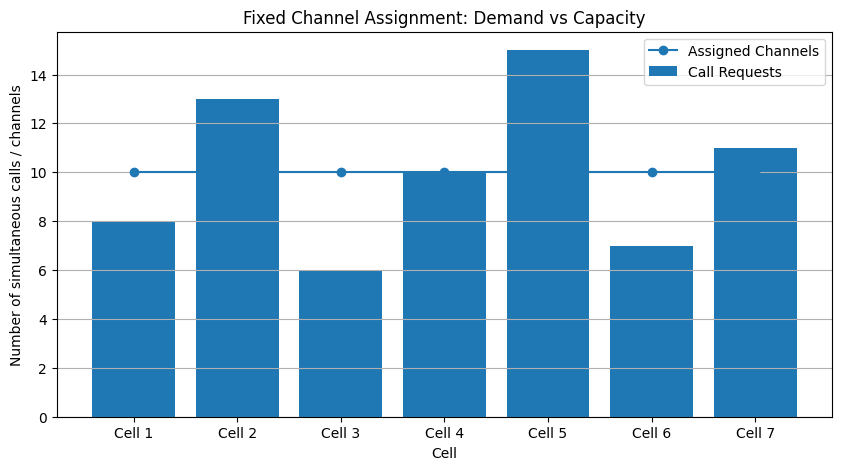

In [3]:
x = np.arange(len(df))

plt.figure(figsize=(10, 5))
plt.bar(x, df["Call Requests"], label="Call Requests")
plt.plot(x, df["Assigned Channels"], marker="o", label="Assigned Channels")
plt.xticks(x, df["Cell"])
plt.xlabel("Cell")
plt.ylabel("Number of simultaneous calls / channels")
plt.title("Fixed Channel Assignment: Demand vs Capacity")
plt.legend()
plt.grid(axis="y")
plt.show()

**Observation:** Cells with demand greater than their fixed capacity block calls. At the same time, some other cells can still have idle channels. This illustrates the resource inflexibility emphasized in the course discussion of FCA.

In [4]:
total_requested = df["Call Requests"].sum()
total_served = df["Served Calls"].sum()
total_blocked = df["Blocked Calls"].sum()
total_idle = df["Idle Channels"].sum()

print(f"Total requested calls : {total_requested}")
print(f"Total served calls    : {total_served}")
print(f"Total blocked calls   : {total_blocked}")
print(f"Total idle channels   : {total_idle}")

Total requested calls : 70
Total served calls    : 61
Total blocked calls   : 9
Total idle channels   : 9


## Fixed vs Dynamic Assignment — Practical Comparison

| Feature | Fixed Channel Assignment | Dynamic / Non-Fixed Assignment |
|---|---|---|
| Channel ownership | Predetermined per cell | Selected according to current need |
| Complexity | Low | Higher |
| Signalling/control | Lower | Higher |
| Response to uneven traffic | Weak | Better |
| Call blocking under local congestion | Can be high | Can be reduced if reusable channels are available |
| Interference control | Planned in advance | Must be checked during assignment |

## Result and Discussion

The notebook allocates a fixed channel set to each cell and demonstrates local blocking under uneven traffic. This is the main weakness of FCA: resources cannot automatically move to a congested cell.

## Conclusion

Frequency allocation and fixed channel assignment were implemented successfully. The simulation clearly shows the difference between **system-wide unused capacity** and **local channel availability**.

## Viva Questions and Short Answers

1. **What is frequency management?**  
   Planning set-up/voice channels, channel numbering, and grouping according to the system plan.

2. **What is channel assignment?**  
   Allocation of radio channels to cells and mobile users.

3. **What is the main idea of FCA?**  
   Each cell receives a predetermined channel set.

4. **Why can FCA block a call even when the network has idle channels?**  
   Because idle channels in another cell are not automatically available to the congested cell.

5. **What is the main advantage of dynamic assignment?**  
   It adapts channel use to current traffic and can improve spectrum utilization.